In [1]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

from scipy.optimize import leastsq

## functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Constant single elec thresholds (pre determined)

In [106]:
single_elec_axon_thr = 1.49 # 1.49
single_elec_soma_thr = 2.3 # 1.57

## Load data for bielec placement (axon and soma)

In [115]:
dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/sim-data/bielec_rotations/axon_60um/'

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
       data_files.append(file)

# Next, extract data
threshold = []
angles = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        threshold.append(np.abs(data[0][0]))
        angles.append(float(file.split('.')[0]))

threshold_axon = np.array(threshold)
angles_axon = np.array(angles)
threshold_axon = threshold_axon/single_elec_axon_thr
        

In [119]:
dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/sim-data/bielec_rotations/soma_60um/'

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
       data_files.append(file)

# Next, extract data
threshold = []
angles = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        threshold.append(np.abs(data[0][0]))
        angles.append(float(file.split('.')[0]))

threshold_soma = np.array(threshold)
angles_soma = np.array(angles)
threshold_soma = threshold_soma/single_elec_soma_thr

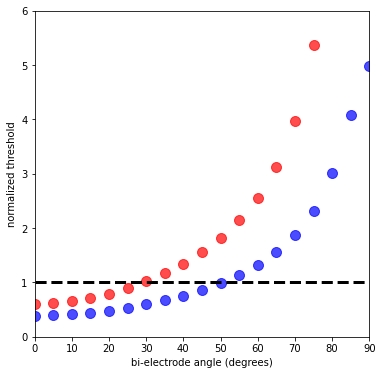

In [120]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

sc = ax.scatter(angles_axon,threshold_axon,s=100,alpha=0.7,c='r')
sc_soma = ax.scatter(angles_soma,threshold_soma,s=100,alpha=0.7,c='b')

# draw a horizontal line at y=1
plt.axhline(y=1, color='k', linestyle='--', linewidth=3)

# ax.set_aspect('equal')
ax.set_xlabel('bi-electrode angle (degrees)')
ax.set_ylabel('normalized threshold')

ax.set_xlim(0,90)
ax.set_ylim(0,6)

fig.savefig('bielec_suppression.pdf', bbox_inches='tight')